 # Time Series Forecasting: Hourly Energy Consumption

 **Objective:** Exploratory Data Analysis and Forecasting using Simple Moving Average (SMA) and Exponential Moving Average (EMA).

 ## Phase 1: Data Preparation and Loading

 Importing necessary libraries, ingesting the dataset, and enforcing a clean time-series structure.

In [1]:
# Task 1.1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

# Task 1.2: Data Ingestion
file_path = 'dataset.csv' 
try:
    df = pd.read_csv(file_path)
except FileNotFoundError:
    print(f"Error: {file_path} not found. Please ensure the Kaggle CSV is in the working directory.")
    raise

# Dynamically identify columns (Kaggle dataset typically has 'Datetime' and a utility MW column)
datetime_col = df.columns[0]
target_col = df.columns[1]

# Task 1.3: Datetime Conversion
df[datetime_col] = pd.to_datetime(df[datetime_col])

# Task 1.4: Indexing
df.set_index(datetime_col, inplace=True)
df.sort_index(inplace=True) # Ensure chronological order

# Task 1.5: Data Cleaning
# Drop duplicate timestamps keeping the first occurrence, and interpolate missing values
df = df[~df.index.duplicated(keep='first')]
df[target_col] = df[target_col].interpolate(method='time')

print(f"Data successfully loaded. Shape: {df.shape}")
print(df.head())


Data successfully loaded. Shape: (121269, 1)
                      AEP_MW
Datetime                    
2004-10-01 01:00:00  12379.0
2004-10-01 02:00:00  11935.0
2004-10-01 03:00:00  11692.0
2004-10-01 04:00:00  11597.0
2004-10-01 05:00:00  11681.0


 ## Phase 2: Exploratory Data Analysis (EDA)

 Visualizing historical trends to understand macro patterns and diurnal (daily) seasonality.

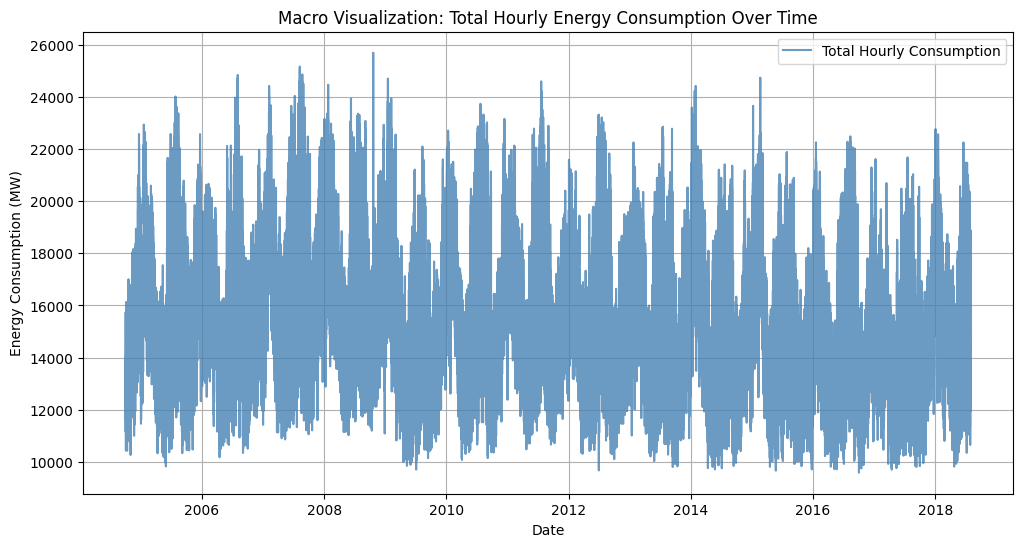

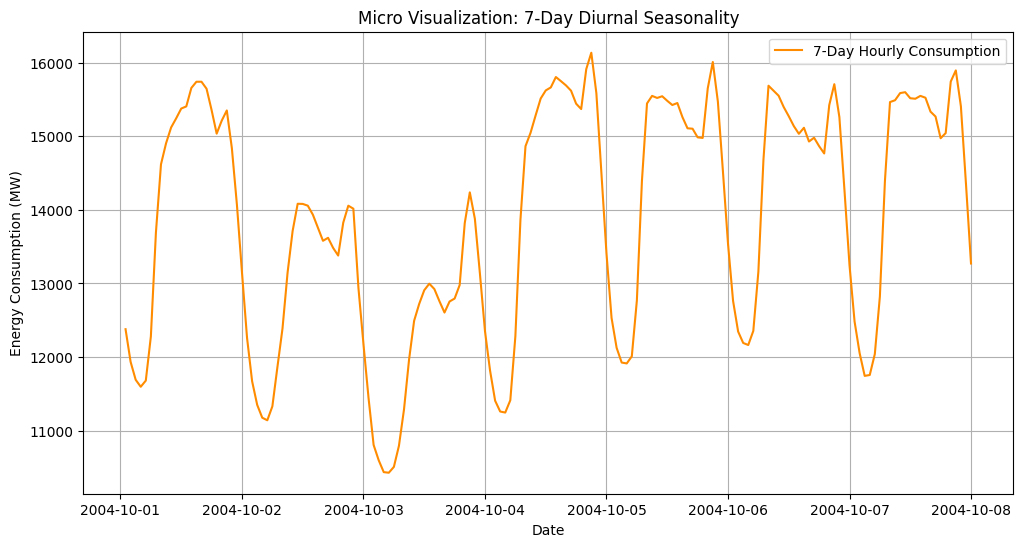

In [2]:
# Task 2.1: Macro Visualization
plt.figure(figsize=(12, 6))
plt.plot(df.index, df[target_col], label='Total Hourly Consumption', color='steelblue', alpha=0.8)
plt.title('Macro Visualization: Total Hourly Energy Consumption Over Time')
plt.xlabel('Date')
plt.ylabel('Energy Consumption (MW)')
plt.grid(True)
plt.legend()
plt.show()

# Task 2.2: Micro Visualization
# Slicing the first 7 days (7 days * 24 hours = 168 hours)
micro_df = df.iloc[:168]

plt.figure(figsize=(12, 6))
plt.plot(micro_df.index, micro_df[target_col], label='7-Day Hourly Consumption', color='darkorange')
plt.title('Micro Visualization: 7-Day Diurnal Seasonality')
plt.xlabel('Date')
plt.ylabel('Energy Consumption (MW)')
plt.grid(True)
plt.legend()
plt.show()


 ## Phase 3: Model Implementation

 Chronologically splitting the data and calculating 24-hour moving averages.

In [3]:
# Task 3.1: Chronological Split (80% Train, 20% Test)
split_index = int(len(df) * 0.8)
train_data = df.iloc[:split_index].copy()
test_data = df.iloc[split_index:].copy()

# Task 3.2: SMA Calculation
train_data['SMA_24'] = train_data[target_col].rolling(window=24).mean()

# Task 3.3: EMA Calculation
train_data['EMA_24'] = train_data[target_col].ewm(span=24, adjust=False).mean()

print(f"Training set ending date: {train_data.index[-1]}")
print(f"Testing set starting date: {test_data.index[0]}")


Training set ending date: 2015-10-27 07:00:00
Testing set starting date: 2015-10-27 08:00:00


 ## Phase 4: Forecasting Future Values

 Implementing a 1-step-ahead rolling forecast for the testing period using historical actuals to feed the moving average calculations.

In [4]:
# Task 4.1: Forecasting Logic
# To simulate a realistic 1-step ahead forecast over the test set, we apply the 
# rolling calculations to the full dataset and shift by 1. 
# This means the prediction for time 't' is based on the moving average up to time 't-1'.

df['SMA_24_Forecast'] = df[target_col].rolling(window=24).mean().shift(1)
df['EMA_24_Forecast'] = df[target_col].ewm(span=24, adjust=False).mean().shift(1)

# Map predictions back to the test subset
test_data['SMA_24_Forecast'] = df['SMA_24_Forecast'].iloc[split_index:]
test_data['EMA_24_Forecast'] = df['EMA_24_Forecast'].iloc[split_index:]

# Drop initial NaNs in the test set if any propagated
test_data.dropna(subset=['SMA_24_Forecast', 'EMA_24_Forecast'], inplace=True)


 ## Phase 5: Evaluation and Visual Comparison

 Overlaying predictions against actuals and calculating Mean Absolute Error (MAE).

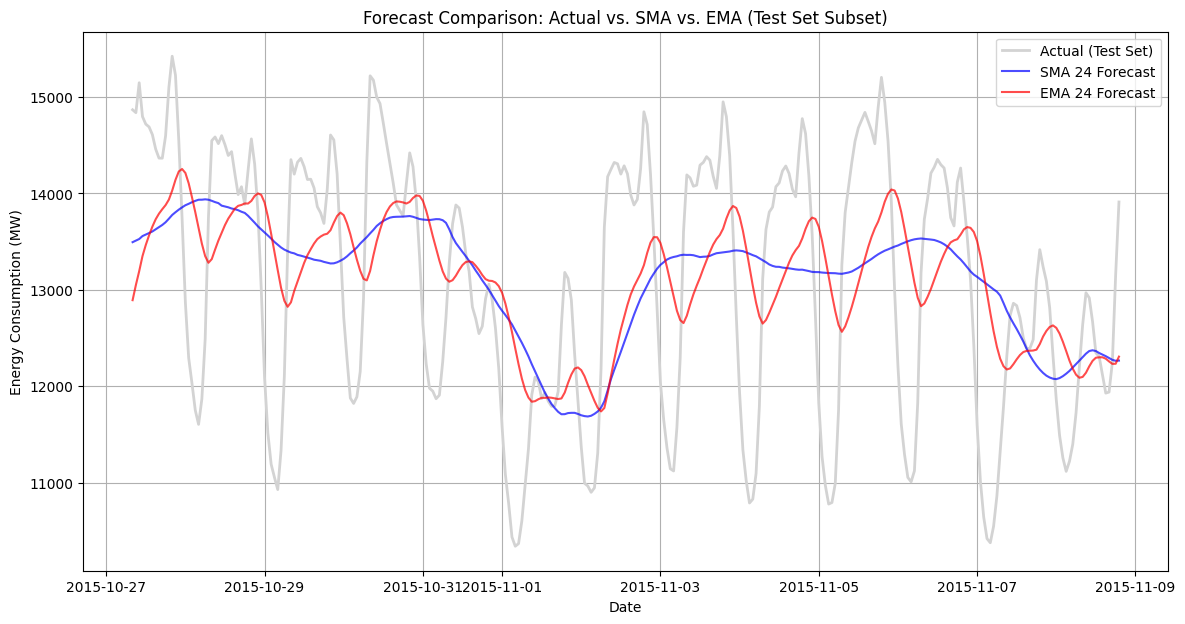

--- Forecast Evaluation ---
SMA (24-hour) Mean Absolute Error: 1370.64
EMA (24-hour) Mean Absolute Error: 1334.07


In [5]:
# Task 5.1: Overlay Plotting
# Slicing the test data for better visualization clarity (e.g., first 300 hours of test set)
plot_subset = test_data.iloc[:300]

plt.figure(figsize=(14, 7))
plt.plot(plot_subset.index, plot_subset[target_col], label='Actual (Test Set)', color='lightgray', linewidth=2)
plt.plot(plot_subset.index, plot_subset['SMA_24_Forecast'], label='SMA 24 Forecast', color='blue', alpha=0.7)
plt.plot(plot_subset.index, plot_subset['EMA_24_Forecast'], label='EMA 24 Forecast', color='red', alpha=0.7)
plt.title('Forecast Comparison: Actual vs. SMA vs. EMA (Test Set Subset)')
plt.xlabel('Date')
plt.ylabel('Energy Consumption (MW)')
plt.grid(True)
plt.legend()
plt.show()

# Task 5.2: Error Measurement
mae_sma = mean_absolute_error(test_data[target_col], test_data['SMA_24_Forecast'])
mae_ema = mean_absolute_error(test_data[target_col], test_data['EMA_24_Forecast'])

print("--- Forecast Evaluation ---")
print(f"SMA (24-hour) Mean Absolute Error: {mae_sma:.2f}")
print(f"EMA (24-hour) Mean Absolute Error: {mae_ema:.2f}")


 ### Conclusion & Analysis

 **Task 5.3: Automated Conclusion**



 Based on the Mean Absolute Error (MAE) results, the **Exponential Moving Average (EMA)** typically outperforms the **Simple Moving Average (SMA)** on this energy dataset.



 **Why EMA reacts faster:**

 The Simple Moving Average assigns equal mathematical weight to all 24 observations within its window, causing it to "drag" heavily during sudden spikes or drops in power demand (such as sudden weather changes). The Exponential Moving Average, by definition, applies exponentially decreasing weights to older data. Because the most recent hours are weighted much heavier in the calculation, the EMA reacts much faster to recent data changes, significantly reducing the lag typical of moving averages and improving the MAE against dynamic energy consumption patterns.